In [44]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt


In [45]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

In [46]:
x,y=make_blobs(1000,n_features=2,centers=4,cluster_std=1.5,random_state=42)

In [47]:
x

array([[-8.41339595,  6.93516545],
       [-5.76648413, -6.43117072],
       [-6.04213682, -6.76610151],
       ...,
       [ 3.2157805 ,  5.92174278],
       [-7.79389549, -7.16056655],
       [-9.6815798 ,  7.0096901 ]])

In [48]:
x=torch.from_numpy(x)
y=torch.from_numpy(y)

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25)

In [49]:
x_train.shape
x_test.shape

torch.Size([250, 2])

In [50]:
model=nn.Sequential(
    nn.Linear(in_features=2,out_features=10),
    nn.ReLU(),
    nn.Linear(in_features=10,out_features=10),
    nn.ReLU(),
    nn.Linear(in_features=10,out_features=4)
).to('mps')

In [51]:
class blobModel(nn.Module):
    def __init__(self,input_features,output_features,hidden_units=8):
        super().__init__()
        self.stack=nn.Sequential(
                                nn.Linear(in_features=input_features,out_features=hidden_units),
                                #nn.ReLU(),
                                nn.Linear(in_features=hidden_units,out_features=hidden_units),
                                #nn.ReLU(),
                                 nn.Linear(in_features=hidden_units,out_features=hidden_units),
                            #3nn.ReLU(),
                                nn.Linear(in_features=hidden_units,out_features=output_features)
        )
    def forward(self,x):
        return self.stack(x)
        
    

In [52]:
torch.unique(y_train)
model1=blobModel(2,4).to('mps')

In [53]:
model1.state_dict()

OrderedDict([('stack.0.weight',
              tensor([[ 0.3724,  0.3338],
                      [-0.6325, -0.5233],
                      [ 0.3564,  0.6171],
                      [ 0.5048,  0.6779],
                      [ 0.1158, -0.5971],
                      [ 0.1544,  0.4080],
                      [ 0.6229, -0.6981],
                      [-0.4766, -0.1111]], device='mps:0')),
             ('stack.0.bias',
              tensor([-0.6049,  0.6221,  0.5677, -0.1486, -0.4570, -0.5815, -0.3260, -0.1118],
                     device='mps:0')),
             ('stack.1.weight',
              tensor([[-0.1734, -0.0347,  0.0272,  0.2590,  0.2421,  0.3170, -0.0316, -0.0707],
                      [-0.1086, -0.1143,  0.0857,  0.0268, -0.0249, -0.0087, -0.0180, -0.2201],
                      [ 0.2332,  0.3209,  0.0258, -0.0398, -0.2682,  0.0884, -0.0623,  0.3279],
                      [ 0.1850,  0.1581,  0.3092, -0.1980, -0.3027,  0.1345, -0.0180,  0.1025],
                      [ 0.0942, -

In [54]:
x_train=x_train.type(torch.float32).to('mps')
y_train=y_train.type(torch.float32).to('mps')
x_test=x_test.type(torch.float32).to('mps')
y_test=y_test.type(torch.float32).to('mps')


In [55]:
model.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.5865, -0.4247],
                      [-0.3206, -0.0509],
                      [-0.1761, -0.3441],
                      [ 0.3537, -0.0232],
                      [ 0.0524, -0.6340],
                      [ 0.5135,  0.4585],
                      [ 0.2035, -0.6652],
                      [-0.2585,  0.1525],
                      [ 0.2269, -0.1031],
                      [ 0.4544, -0.0507]], device='mps:0')),
             ('0.bias',
              tensor([ 0.1829,  0.6706, -0.1775, -0.2056,  0.5855,  0.6444,  0.3296,  0.3558,
                      -0.6778,  0.3712], device='mps:0')),
             ('2.weight',
              tensor([[-0.1371,  0.0221,  0.0097, -0.1014,  0.0746, -0.0943,  0.2717, -0.1783,
                        0.0469, -0.0484],
                      [-0.0174,  0.0749,  0.1401,  0.0181,  0.1623,  0.2825, -0.2505, -0.2637,
                       -0.1272,  0.3135],
                      [ 0.0241, -0.0470, -0.0612, -0.1160,

## lets train the model

In [56]:
## we use the CrossEntropyLoss()


In [57]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model1.parameters(),lr=0.1)

In [58]:
## learning rate is an hyper parameter which can be changed

In [59]:
## 8.4 building a training loop

In [60]:
with torch.inference_mode():
    y_pp=model(x_test)
y_pp

tensor([[-3.3219e-01, -3.3734e-01,  5.7733e-01, -2.0385e-01],
        [-1.3484e-01, -4.0207e-01,  2.8996e-01, -1.2789e-02],
        [-2.6336e-01,  3.4039e-02,  8.4462e-02, -8.4856e-02],
        [-1.7224e-01,  6.1172e-02, -3.2700e-02, -1.2277e-01],
        [-5.2334e-01, -3.9399e-01,  7.1325e-01, -4.4184e-02],
        [-2.2560e-01,  3.5747e-01,  3.2164e-03, -1.6486e-01],
        [-4.2239e-01, -3.9683e-01,  7.2141e-01, -2.2994e-01],
        [-2.6808e-01,  6.7897e-02,  3.1597e-02, -7.0639e-02],
        [-2.0726e-01,  2.9433e-01,  8.2214e-04, -1.8328e-01],
        [-1.9889e-01,  2.7112e-01,  1.7427e-02, -1.8335e-01],
        [-4.2279e-01, -3.9359e-01,  6.5699e-01, -1.5946e-01],
        [-2.4975e-01, -2.3828e-01,  4.9333e-01, -1.8174e-01],
        [-2.9184e-01,  7.2571e-02,  4.2507e-02, -5.6674e-02],
        [-1.4394e-01,  6.6565e-02, -2.0107e-02, -1.6351e-01],
        [-1.0151e-01, -1.3372e-01,  1.8197e-01, -1.0447e-01],
        [-2.3689e-01,  3.4000e-01,  4.4914e-03, -1.8084e-01],
        

In [61]:
## loss function will give how wrong the outputs

In [62]:
next(model1.parameters()).device

device(type='mps', index=0)

In [63]:
y_test


tensor([1., 2., 0., 0., 1., 3., 1., 0., 3., 3., 1., 1., 0., 0., 2., 3., 0., 1.,
        2., 0., 2., 3., 1., 1., 0., 3., 2., 0., 3., 2., 2., 0., 1., 3., 3., 3.,
        1., 1., 3., 1., 1., 0., 0., 2., 0., 3., 0., 0., 0., 2., 0., 3., 0., 1.,
        2., 2., 3., 2., 3., 2., 2., 0., 3., 3., 3., 2., 0., 1., 0., 0., 3., 0.,
        1., 2., 3., 0., 1., 2., 1., 2., 0., 0., 3., 3., 2., 0., 1., 3., 2., 3.,
        2., 1., 2., 3., 1., 3., 1., 0., 2., 1., 0., 0., 3., 0., 3., 1., 2., 0.,
        3., 3., 3., 1., 2., 3., 3., 3., 0., 1., 2., 0., 0., 2., 3., 3., 1., 1.,
        2., 3., 3., 0., 0., 3., 1., 3., 3., 1., 0., 1., 3., 2., 2., 0., 3., 0.,
        1., 0., 2., 3., 2., 0., 1., 1., 1., 2., 3., 0., 0., 2., 3., 3., 1., 1.,
        0., 0., 3., 0., 3., 2., 1., 3., 0., 1., 3., 3., 3., 1., 1., 1., 0., 3.,
        0., 0., 1., 0., 0., 1., 2., 3., 2., 0., 0., 2., 3., 2., 2., 3., 1., 3.,
        1., 0., 0., 2., 2., 1., 2., 2., 3., 2., 3., 3., 3., 1., 1., 2., 1., 0.,
        1., 2., 0., 2., 1., 3., 3., 2., 

In [64]:
## to avaluate and train and test mdoel we need to convert the logits to the prediction 
##proabalitities

In [65]:
## by using the activation we use the softmax

In [66]:
## convert thr logits outputs to the proababilityes
print(y_pp)
y_pred=torch.softmax(y_pp,dim=1)

tensor([[-3.3219e-01, -3.3734e-01,  5.7733e-01, -2.0385e-01],
        [-1.3484e-01, -4.0207e-01,  2.8996e-01, -1.2789e-02],
        [-2.6336e-01,  3.4039e-02,  8.4462e-02, -8.4856e-02],
        [-1.7224e-01,  6.1172e-02, -3.2700e-02, -1.2277e-01],
        [-5.2334e-01, -3.9399e-01,  7.1325e-01, -4.4184e-02],
        [-2.2560e-01,  3.5747e-01,  3.2164e-03, -1.6486e-01],
        [-4.2239e-01, -3.9683e-01,  7.2141e-01, -2.2994e-01],
        [-2.6808e-01,  6.7897e-02,  3.1597e-02, -7.0639e-02],
        [-2.0726e-01,  2.9433e-01,  8.2214e-04, -1.8328e-01],
        [-1.9889e-01,  2.7112e-01,  1.7427e-02, -1.8335e-01],
        [-4.2279e-01, -3.9359e-01,  6.5699e-01, -1.5946e-01],
        [-2.4975e-01, -2.3828e-01,  4.9333e-01, -1.8174e-01],
        [-2.9184e-01,  7.2571e-02,  4.2507e-02, -5.6674e-02],
        [-1.4394e-01,  6.6565e-02, -2.0107e-02, -1.6351e-01],
        [-1.0151e-01, -1.3372e-01,  1.8197e-01, -1.0447e-01],
        [-2.3689e-01,  3.4000e-01,  4.4914e-03, -1.8084e-01],
        

In [67]:
print(y_pred)
y_label=torch.argmax(y_pred,dim=1)
print(y_label)

tensor([[0.1781, 0.1772, 0.4422, 0.2025],
        [0.2260, 0.1730, 0.3456, 0.2553],
        [0.2017, 0.2716, 0.2856, 0.2411],
        [0.2240, 0.2829, 0.2576, 0.2354],
        [0.1390, 0.1581, 0.4785, 0.2244],
        [0.1956, 0.3505, 0.2459, 0.2079],
        [0.1568, 0.1609, 0.4922, 0.1901],
        [0.2013, 0.2817, 0.2717, 0.2453],
        [0.2038, 0.3365, 0.2509, 0.2087],
        [0.2059, 0.3294, 0.2556, 0.2091],
        [0.1594, 0.1641, 0.4692, 0.2074],
        [0.1929, 0.1951, 0.4055, 0.2065],
        [0.1960, 0.2822, 0.2738, 0.2480],
        [0.2301, 0.2840, 0.2604, 0.2256],
        [0.2329, 0.2255, 0.3093, 0.2322],
        [0.1957, 0.3484, 0.2491, 0.2069],
        [0.2183, 0.2845, 0.2587, 0.2385],
        [0.1560, 0.1643, 0.4669, 0.2128],
        [0.2198, 0.1585, 0.3613, 0.2604],
        [0.2104, 0.2744, 0.2769, 0.2383],
        [0.2168, 0.1585, 0.3621, 0.2626],
        [0.2022, 0.3341, 0.2552, 0.2085],
        [0.1545, 0.1600, 0.4852, 0.2002],
        [0.1758, 0.1876, 0.4133, 0

In [68]:
def accuracy(y_pred,y_train):
    correct=torch.eq(y_pred,y_train).sum().item()
    acc=correct/len(y_train)
    return acc

In [69]:
epoch=500
l=[]
a1=[]
for i in range(epoch):
    model1.train()
    y_logit=model1(x_train)
    y_pred=torch.softmax(y_logit,dim=1)
    y_label=torch.argmax(y_pred,dim=1)
    loss=loss_fn(y_pred,y_train)
    print(loss)
    a=accuracy(y_label,y_train)
    print(a)
    a1.append(a)
    l.append(loss.to('cpu').detach().numpy())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

tensor(1.3815, device='mps:0', grad_fn=<NllLossBackward0>)
0.06133333333333333
tensor(1.3310, device='mps:0', grad_fn=<NllLossBackward0>)
0.244
tensor(1.2853, device='mps:0', grad_fn=<NllLossBackward0>)
0.4093333333333333
tensor(1.2415, device='mps:0', grad_fn=<NllLossBackward0>)
0.6666666666666666
tensor(1.1977, device='mps:0', grad_fn=<NllLossBackward0>)
0.732
tensor(1.1539, device='mps:0', grad_fn=<NllLossBackward0>)
0.7653333333333333
tensor(1.1131, device='mps:0', grad_fn=<NllLossBackward0>)
0.808
tensor(1.0786, device='mps:0', grad_fn=<NllLossBackward0>)
0.8306666666666667
tensor(1.0510, device='mps:0', grad_fn=<NllLossBackward0>)
0.8386666666666667
tensor(1.0288, device='mps:0', grad_fn=<NllLossBackward0>)
0.8573333333333333
tensor(1.0100, device='mps:0', grad_fn=<NllLossBackward0>)
0.8706666666666667
tensor(0.9929, device='mps:0', grad_fn=<NllLossBackward0>)
0.8946666666666667
tensor(0.9769, device='mps:0', grad_fn=<NllLossBackward0>)
0.9106666666666666
tensor(0.9612, device='m

In [70]:
print(y_label)

tensor([2, 2, 0, 2, 2, 1, 2, 0, 2, 2, 0, 0, 1, 3, 2, 3, 2, 1, 2, 2, 3, 0, 3, 3,
        3, 2, 2, 1, 2, 2, 2, 2, 3, 1, 1, 3, 0, 2, 0, 1, 2, 3, 3, 1, 2, 3, 2, 0,
        0, 0, 1, 0, 3, 0, 2, 2, 3, 2, 3, 3, 3, 0, 0, 2, 3, 2, 0, 1, 0, 2, 1, 1,
        1, 0, 1, 1, 0, 1, 2, 2, 2, 2, 1, 2, 1, 2, 3, 1, 1, 1, 3, 0, 1, 0, 1, 1,
        2, 3, 1, 1, 1, 1, 1, 0, 1, 1, 3, 2, 3, 2, 3, 2, 1, 2, 3, 0, 3, 1, 3, 2,
        0, 1, 1, 1, 3, 3, 2, 2, 2, 0, 3, 1, 2, 3, 2, 0, 3, 1, 3, 1, 3, 2, 3, 3,
        0, 3, 1, 0, 1, 2, 0, 0, 1, 3, 1, 2, 0, 1, 2, 2, 1, 0, 1, 3, 1, 3, 3, 1,
        2, 2, 1, 2, 2, 2, 0, 0, 3, 2, 2, 0, 2, 0, 2, 0, 0, 3, 3, 3, 3, 2, 1, 3,
        0, 1, 1, 3, 3, 2, 3, 2, 2, 0, 3, 1, 3, 3, 0, 3, 2, 3, 1, 3, 0, 3, 0, 2,
        0, 1, 0, 0, 1, 3, 2, 3, 0, 1, 3, 1, 3, 2, 3, 3, 1, 2, 3, 2, 1, 2, 0, 3,
        1, 0, 2, 0, 2, 1, 2, 2, 2, 1, 1, 0, 0, 2, 0, 2, 2, 1, 3, 1, 1, 2, 3, 1,
        1, 3, 1, 0, 1, 0, 2, 1, 2, 3, 0, 3, 1, 1, 2, 0, 3, 3, 2, 3, 0, 1, 1, 0,
        3, 1, 2, 1, 0, 2, 1, 3, 3, 1, 3,

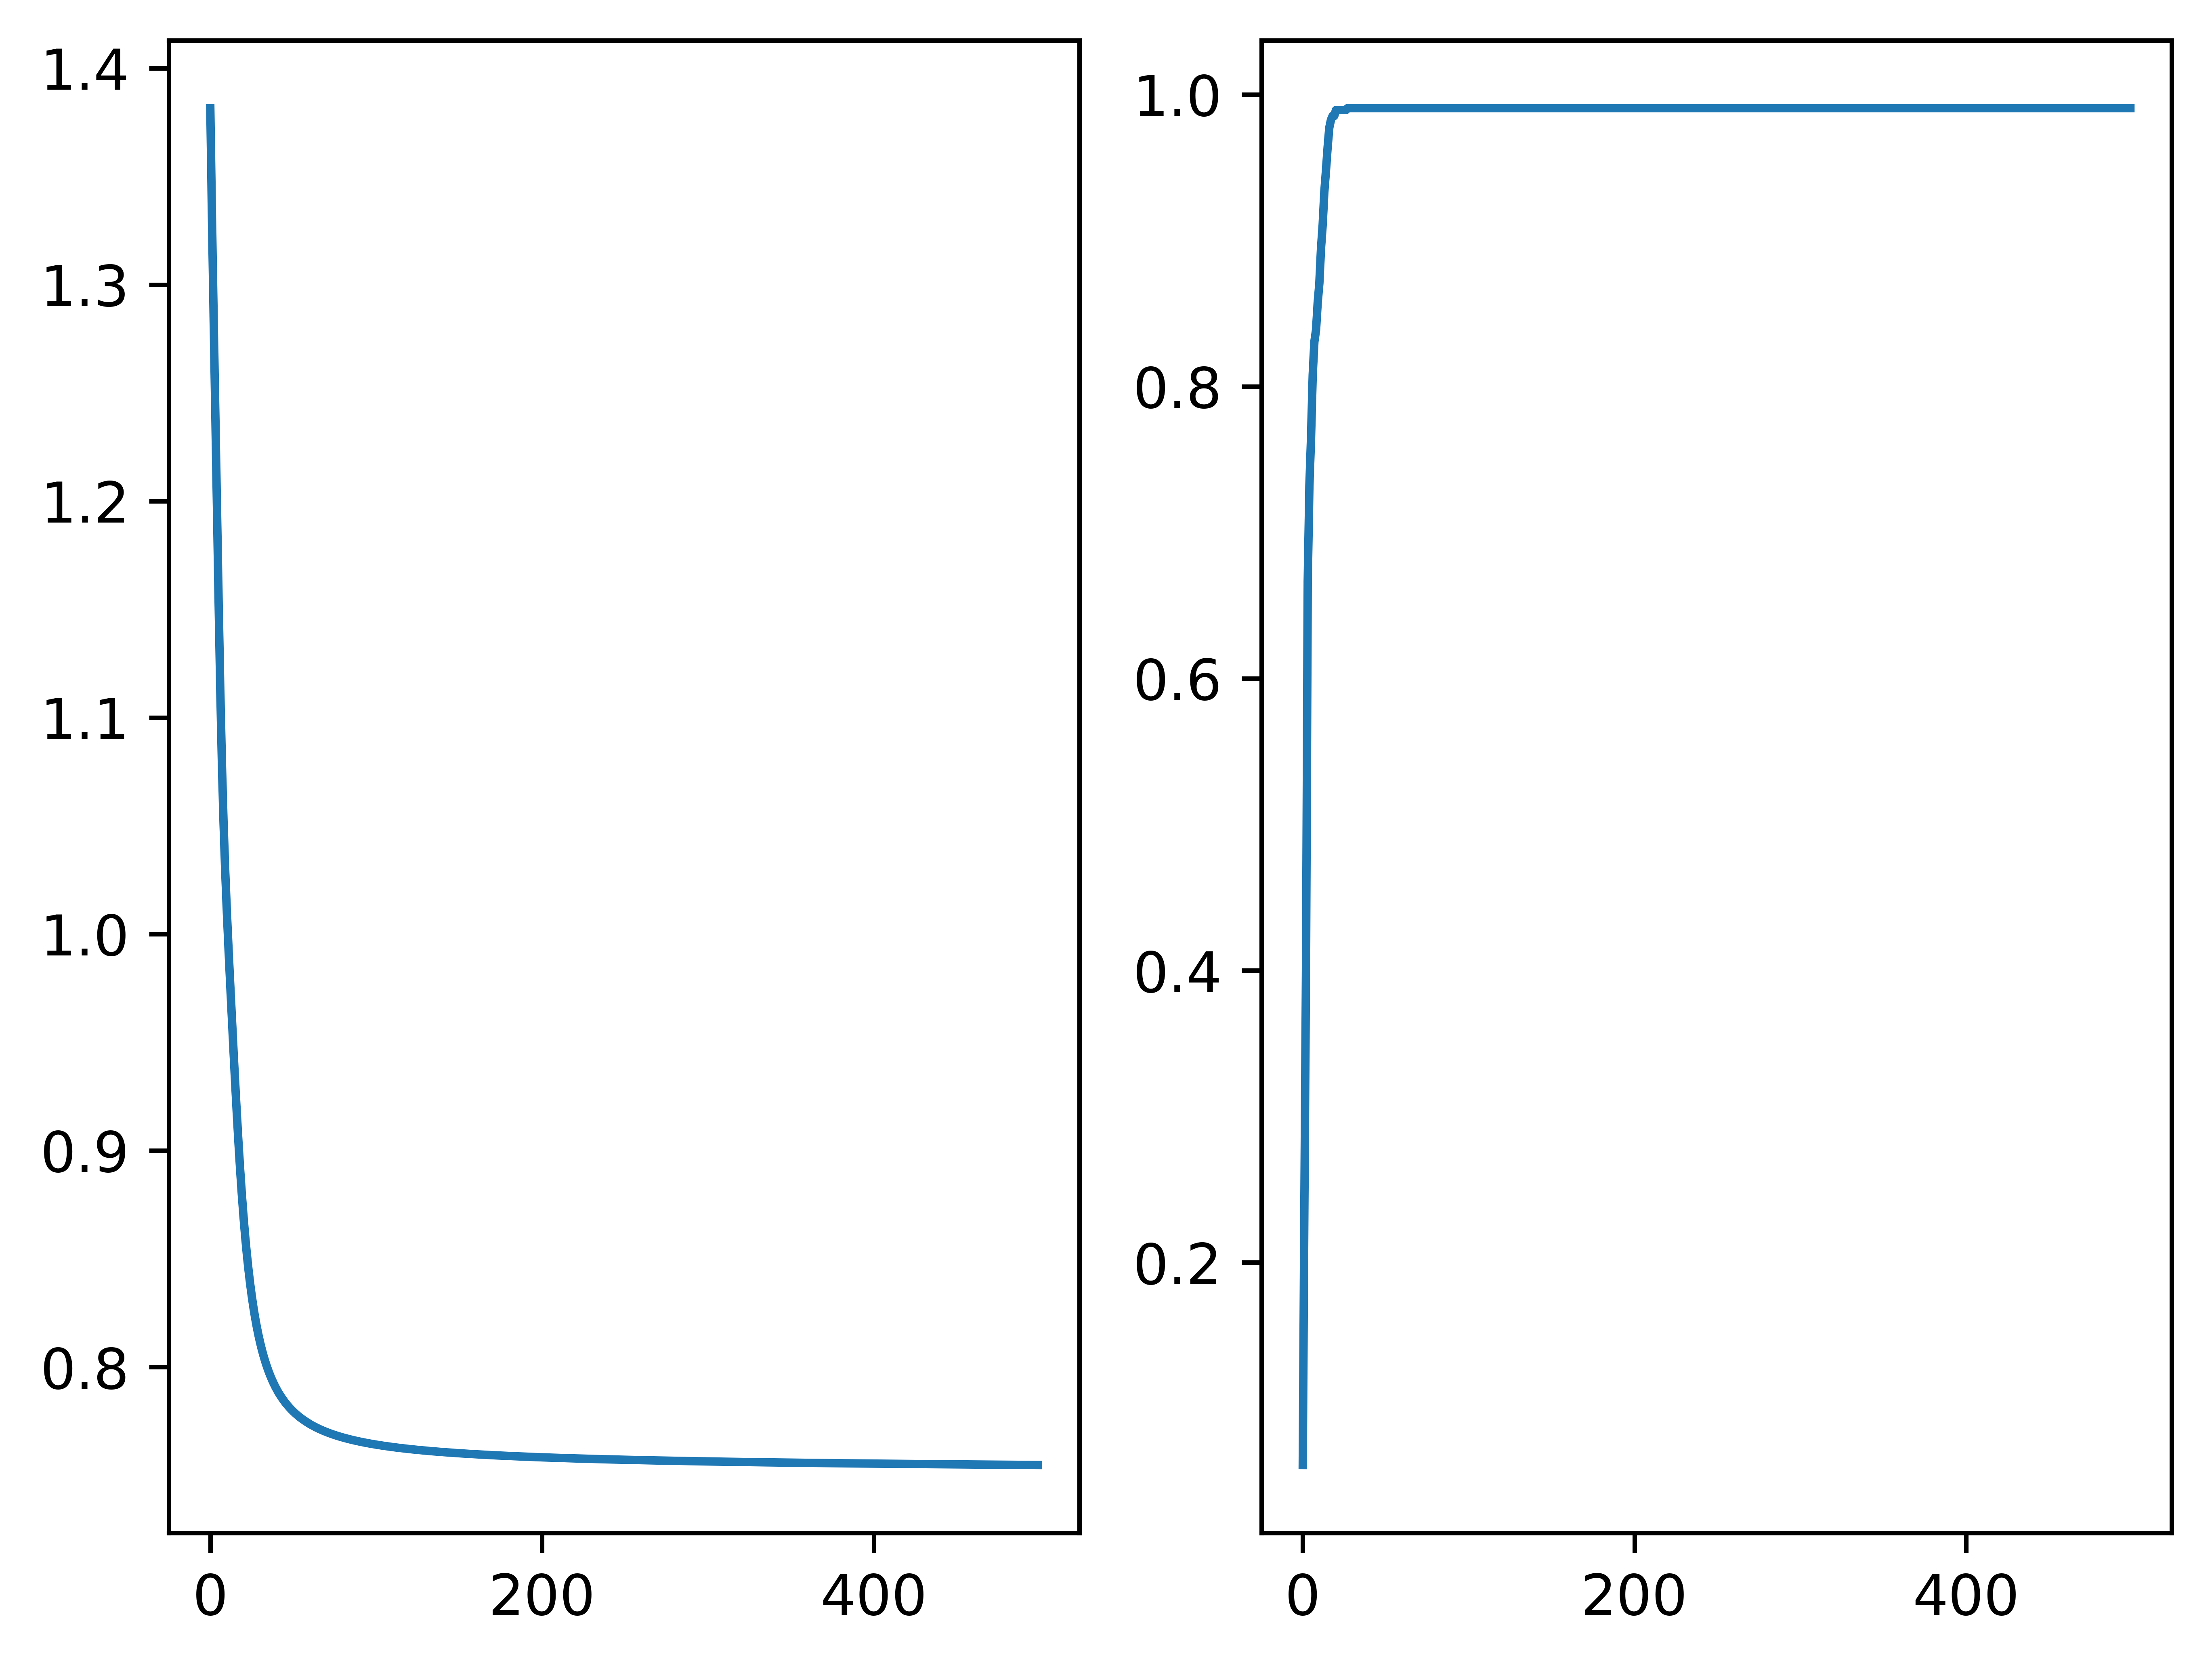

In [71]:
plt.figure(dpi=1000)
plt.subplot(1,2,1)
plt.plot(l)
plt.subplot(1,2,2)
plt.plot(a1)
plt.savefig('multimodel.png')

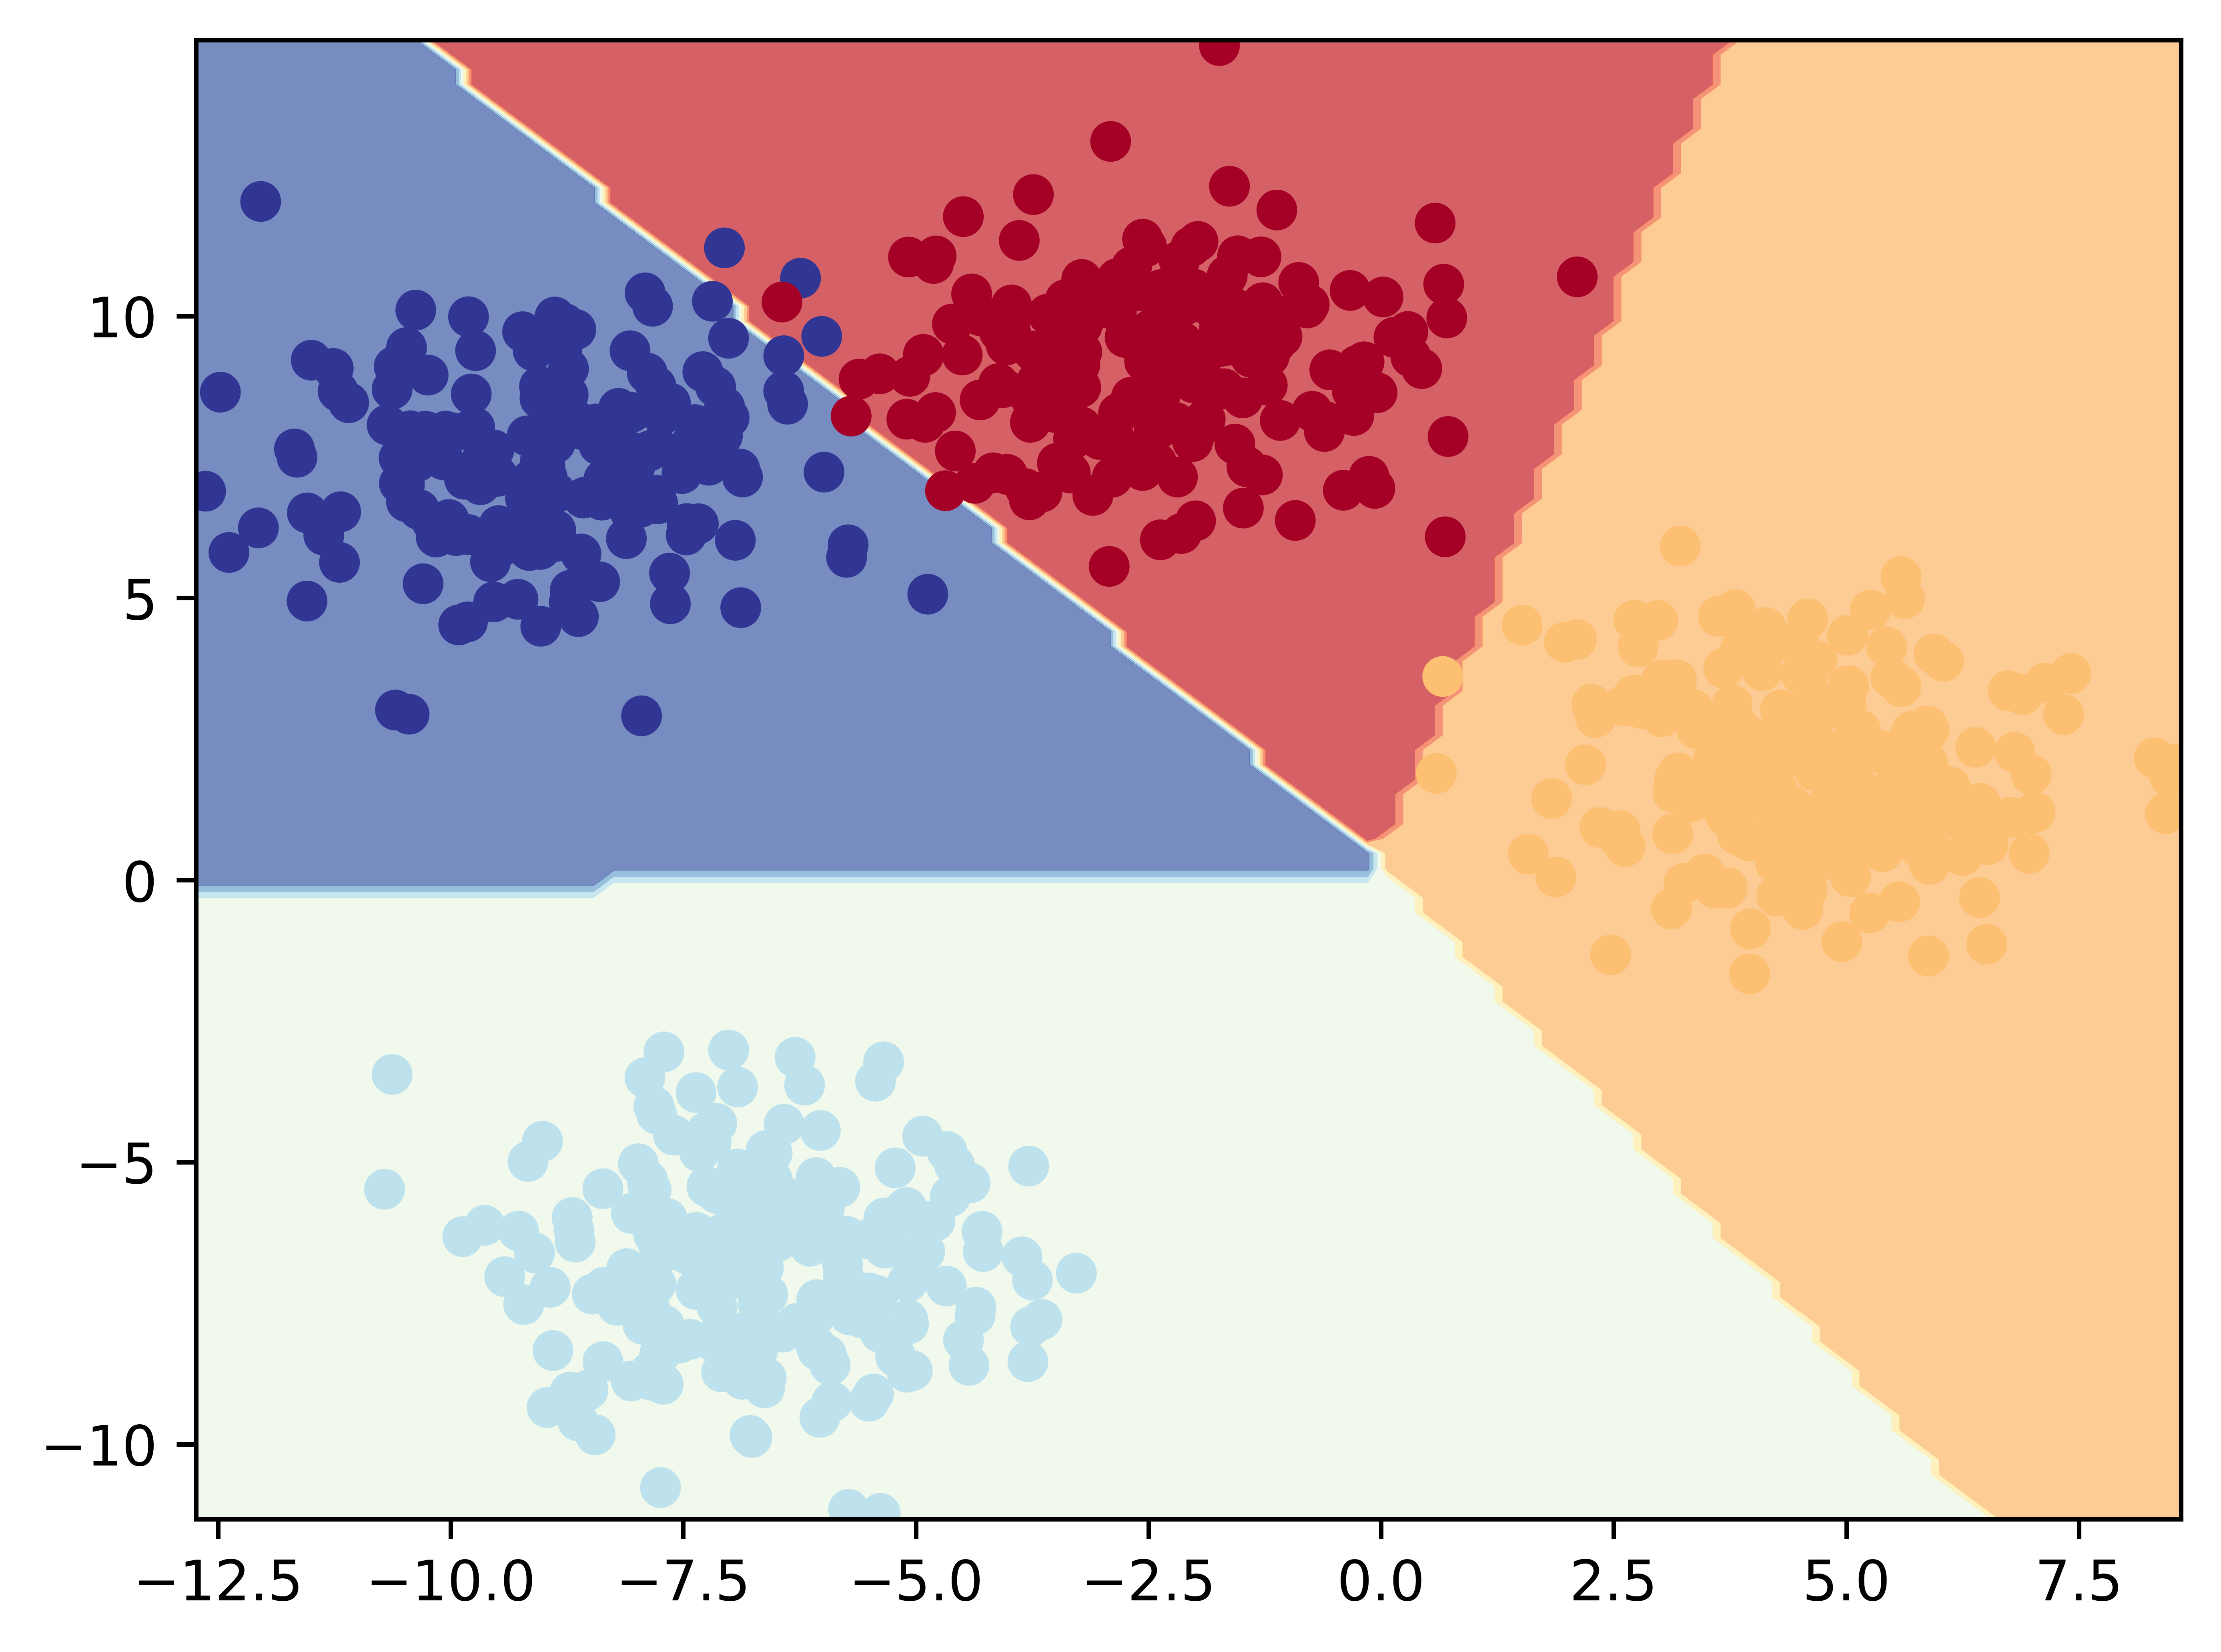

In [72]:
from helper_functions import plot_predictions,plot_decision_boundary
plt.figure(dpi=1000)
plot_decision_boundary(model1,x_train,y_train)
plt.savefig('multiclassboundary.png')

In [73]:
## input batch size to match th size

In [74]:
# datatype issues and shape issues were the modt prominent issues found in pytorch programming

In [75]:
model1.eval()
with torch.inference_mode():
    y_logits=model(x_test)

print(y_logits)

tensor([[-3.3219e-01, -3.3734e-01,  5.7733e-01, -2.0385e-01],
        [-1.3484e-01, -4.0207e-01,  2.8996e-01, -1.2789e-02],
        [-2.6336e-01,  3.4039e-02,  8.4462e-02, -8.4856e-02],
        [-1.7224e-01,  6.1172e-02, -3.2700e-02, -1.2277e-01],
        [-5.2334e-01, -3.9399e-01,  7.1325e-01, -4.4184e-02],
        [-2.2560e-01,  3.5747e-01,  3.2164e-03, -1.6486e-01],
        [-4.2239e-01, -3.9683e-01,  7.2141e-01, -2.2994e-01],
        [-2.6808e-01,  6.7897e-02,  3.1597e-02, -7.0639e-02],
        [-2.0726e-01,  2.9433e-01,  8.2214e-04, -1.8328e-01],
        [-1.9889e-01,  2.7112e-01,  1.7427e-02, -1.8335e-01],
        [-4.2279e-01, -3.9359e-01,  6.5699e-01, -1.5946e-01],
        [-2.4975e-01, -2.3828e-01,  4.9333e-01, -1.8174e-01],
        [-2.9184e-01,  7.2571e-02,  4.2507e-02, -5.6674e-02],
        [-1.4394e-01,  6.6565e-02, -2.0107e-02, -1.6351e-01],
        [-1.0151e-01, -1.3372e-01,  1.8197e-01, -1.0447e-01],
        [-2.3689e-01,  3.4000e-01,  4.4914e-03, -1.8084e-01],
        

In [76]:
y_preds=torch.softmax(y_logits,dim=1)

In [77]:
y_preds

tensor([[0.1781, 0.1772, 0.4422, 0.2025],
        [0.2260, 0.1730, 0.3456, 0.2553],
        [0.2017, 0.2716, 0.2856, 0.2411],
        [0.2240, 0.2829, 0.2576, 0.2354],
        [0.1390, 0.1581, 0.4785, 0.2244],
        [0.1956, 0.3505, 0.2459, 0.2079],
        [0.1568, 0.1609, 0.4922, 0.1901],
        [0.2013, 0.2817, 0.2717, 0.2453],
        [0.2038, 0.3365, 0.2509, 0.2087],
        [0.2059, 0.3294, 0.2556, 0.2091],
        [0.1594, 0.1641, 0.4692, 0.2074],
        [0.1929, 0.1951, 0.4055, 0.2065],
        [0.1960, 0.2822, 0.2738, 0.2480],
        [0.2301, 0.2840, 0.2604, 0.2256],
        [0.2329, 0.2255, 0.3093, 0.2322],
        [0.1957, 0.3484, 0.2491, 0.2069],
        [0.2183, 0.2845, 0.2587, 0.2385],
        [0.1560, 0.1643, 0.4669, 0.2128],
        [0.2198, 0.1585, 0.3613, 0.2604],
        [0.2104, 0.2744, 0.2769, 0.2383],
        [0.2168, 0.1585, 0.3621, 0.2626],
        [0.2022, 0.3341, 0.2552, 0.2085],
        [0.1545, 0.1600, 0.4852, 0.2002],
        [0.1758, 0.1876, 0.4133, 0

In [78]:
y_lab=torch.argmax(y_preds,dim=1)

In [79]:
y_lab

tensor([2, 2, 2, 1, 2, 1, 2, 1, 1, 1, 2, 2, 1, 1, 2, 1, 1, 2, 2, 2, 2, 1, 2, 2,
        1, 1, 2, 1, 1, 2, 2, 1, 2, 1, 1, 1, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1, 2, 1,
        1, 2, 2, 1, 2, 2, 2, 2, 1, 2, 1, 2, 2, 1, 1, 1, 1, 2, 1, 2, 2, 2, 1, 1,
        2, 2, 1, 2, 2, 2, 2, 2, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 2, 2, 2, 1, 2, 1,
        2, 2, 2, 2, 1, 2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1, 1, 1, 2, 2, 2,
        1, 2, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 2, 2, 2, 1, 2, 2, 1, 1, 1,
        2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 1, 1, 1, 2, 1, 1, 2, 2, 1, 2, 1, 2, 1, 2,
        2, 1, 1, 2, 1, 1, 1, 2, 2, 2, 2, 1, 1, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2,
        1, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 1, 1, 2, 2, 2, 2, 1,
        2, 2, 2, 2, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 1,
        1, 2, 1, 2, 2, 1, 2, 2, 1, 1], device='mps:0')

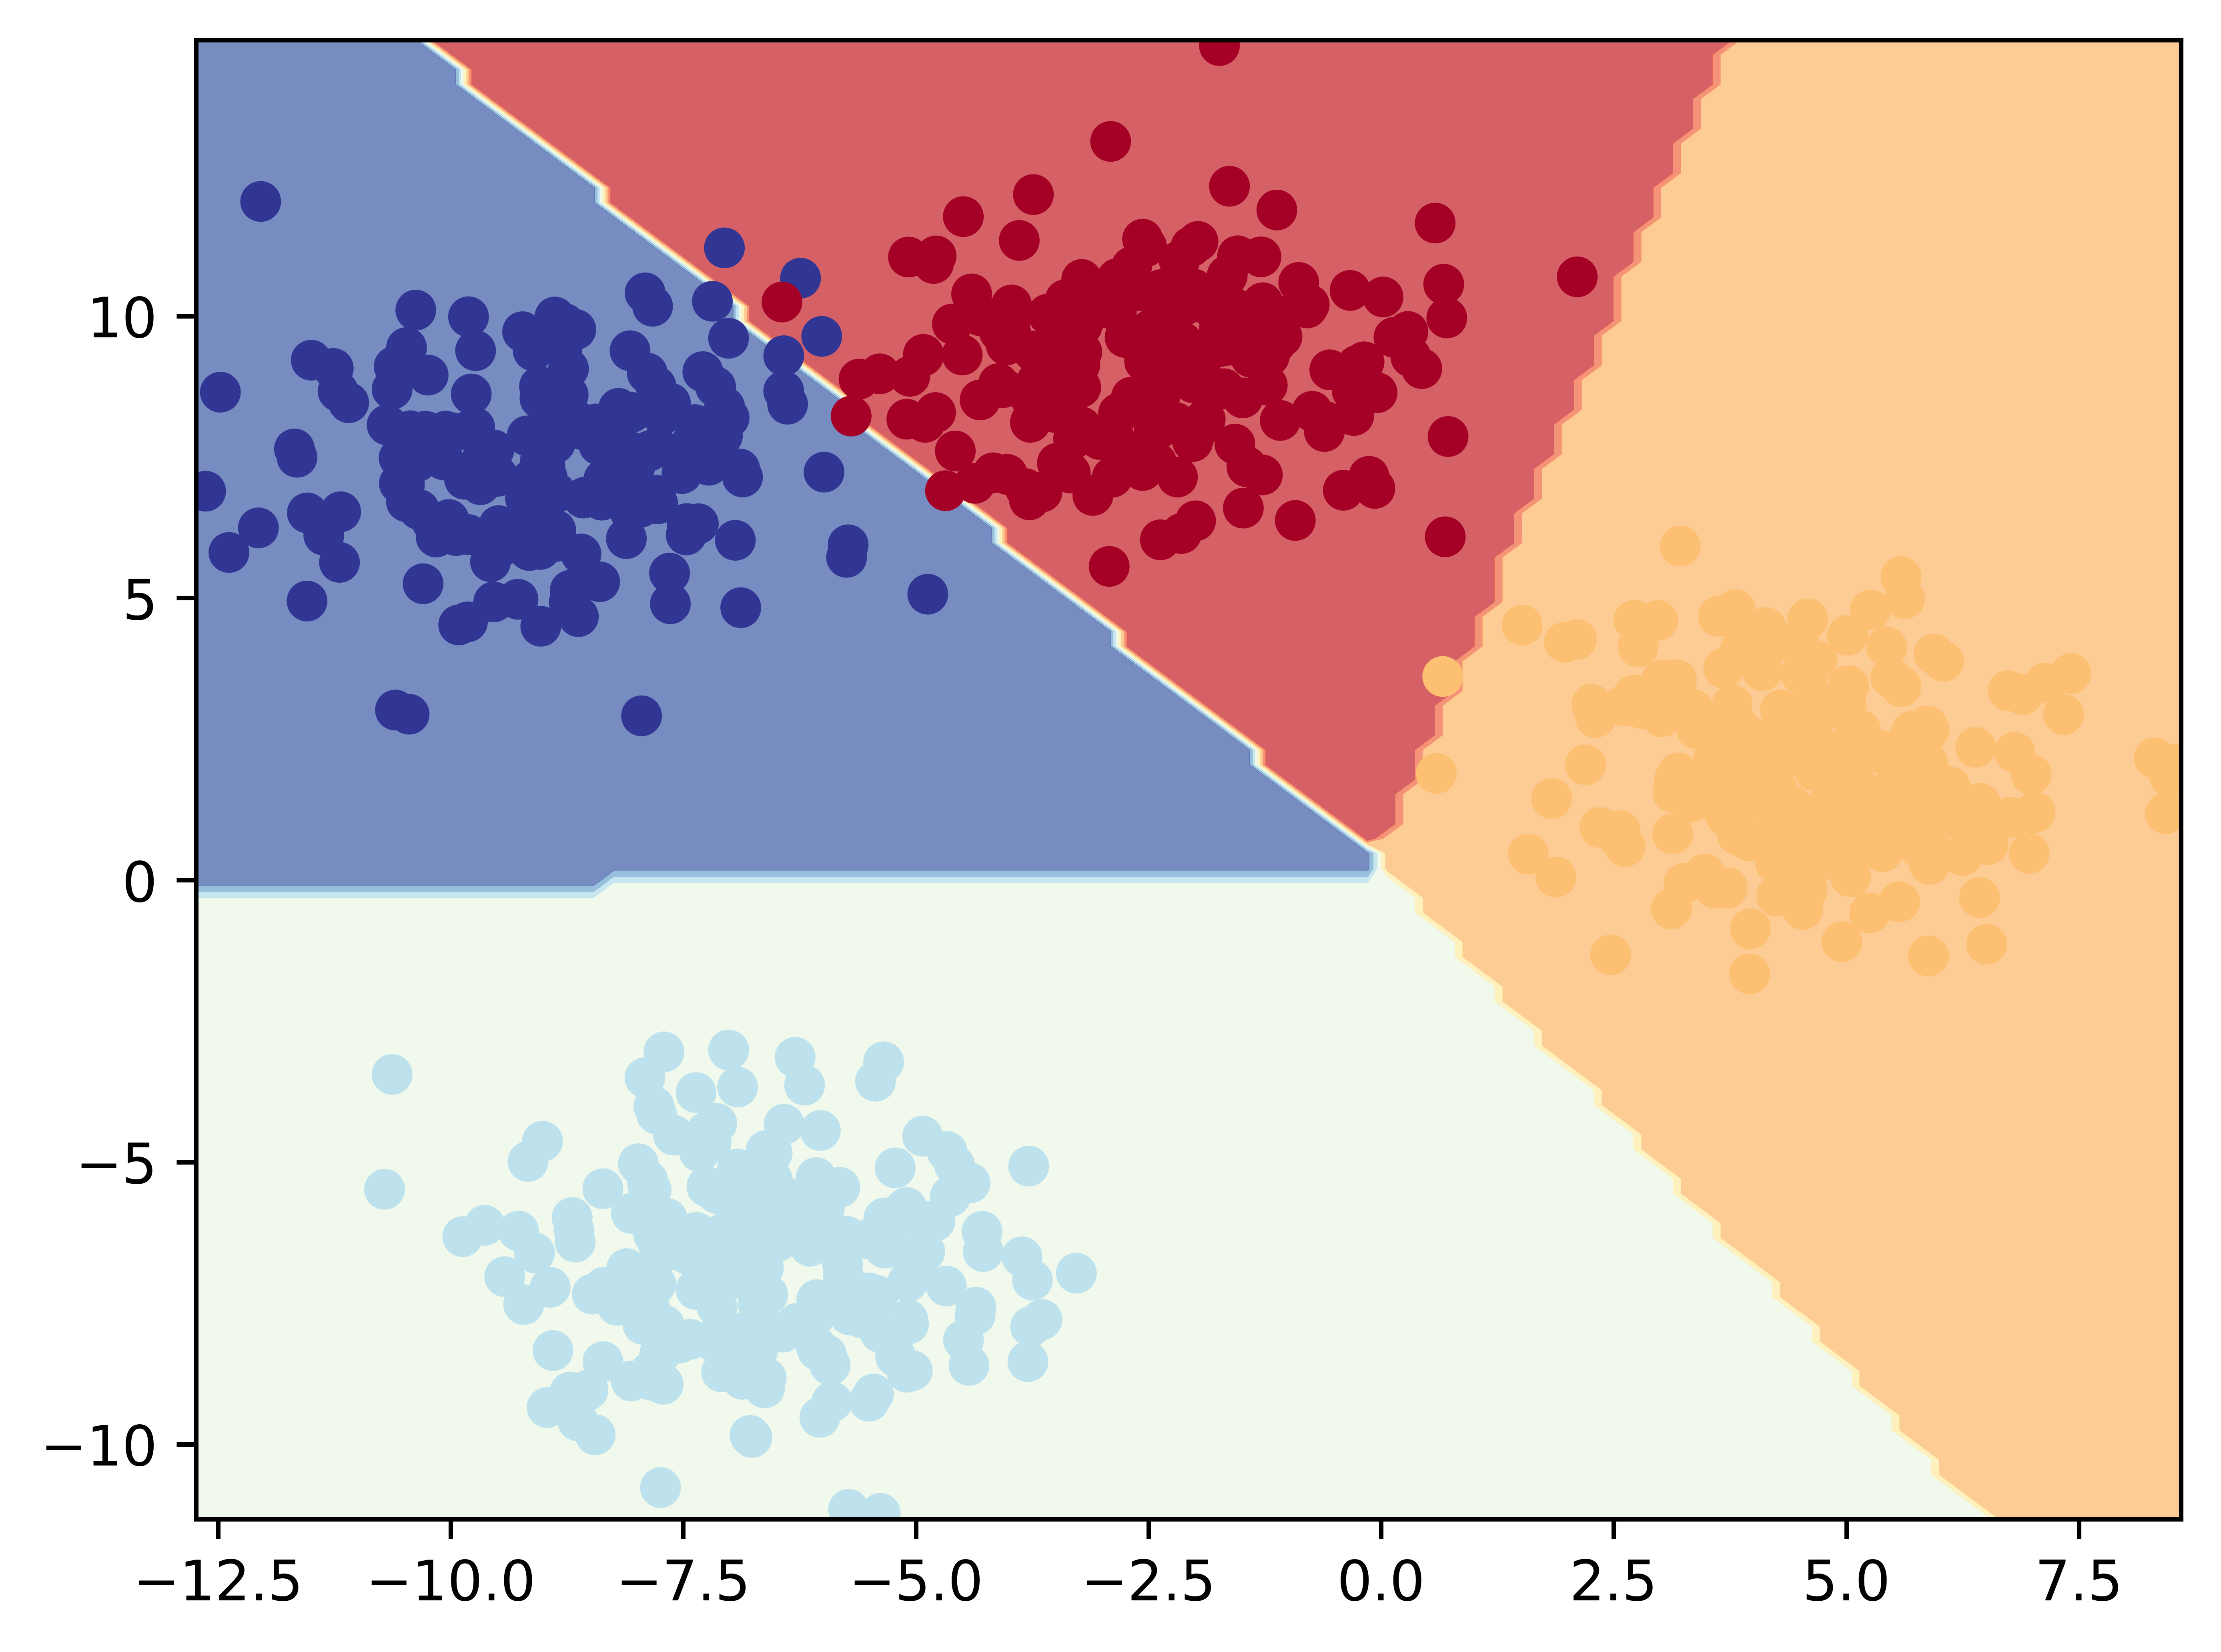

In [82]:
plt.figure(dpi=1000)

plot_decision_boundary(model1,x_train,y_train)


In [83]:
# we can use the linear as we can distinguish using linear lines also

In [84]:
## 9. A few mode classification metrics

In [85]:

## accuracy was also an important 
## precision
## recall


In [86]:
## beyond accuracy
## precision recall tradeoff precision and recall were inversely proportional


In [87]:
## torch metrics

In [88]:
## torchmetrics pytorch like code

In [89]:
pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 927.3/927.3 kB 1.0 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.
